In [1]:
from spin_lattices import KagomeLattice, SpinLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from boolean_analysis import (
    BooleanFourierAnalyzer,
    keep_largest_n,
    keep_everything,
    ScorerType,
    get_scorer,
    SignalOption,
    AmplitudeMedianBinSignalKind,
    SignSignalKind,
    AmplitudeSignalKind,
    SignalKind,
)
from pathlib import Path
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import matplotlib.pyplot as plt
from heisenberg_hamiltonians import batched_state_info_df
from itertools import product
import numpy.typing as npt
from tqdm import tqdm
import seaborn as sns
import parse

from parity import popcount
from kagome_24_fourier_full_2023_01_25 import experiment_dir, accuracy_file, overlap_file

fourier_learners_cache_dir = Path("fourier_learners_cache")
ground_state_cache_dir = Path("groundstates")


def total_hamming_weight(analyzer: BooleanFourierAnalyzer, terms: int) -> int:
    return popcount(np.asarray(analyzer.learner.get_coeffs_ser().iloc[:terms].index)).sum()


def get_score_column(df: pd.DataFrame, scorer: str) -> list:
    return [
        row["analyzer"]
        .truncate(keep_largest_n(row["terms"]))
        .prediction_score(scorer=scorer, max_batch_size=10000)
        for _, row in tqdm(df.iterrows())
    ]


2023-02-01 19:41:49.381 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-02-01 19:41:49.384 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
2023-02-01 19:41:49.449 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
[Debug]   [LOCALE0]   Initializing chpl_kernels ...
set_python_exception_handler ...
/vol/tcm10/ischurov/frustrations-eda/boolean_analysis.py:28: UserWarning: This module is deprecated and will be removed in the future.
  warnings.warn("This module is deprecated and will be removed in the future.")
/vol/tcm10/ischurov/frustrations-eda/boolean_analysis.py:29: UserWarning: Use lattice_boolean_analysis.py instead.
  warnings.warn("Use lattice_boolean_analysis.py instead.")


In [2]:
%matplotlib inline

In [3]:
lattices = {height: KagomeLattice(width=2, height=height) for height in [2, 3, 4]}


In [6]:
accuracy_terms_df = pd.read_csv(accuracy_file).query("J2 < 0.52 or J2 > 0.53")
overlap_terms_df = pd.read_csv(overlap_file).query("J2 < 0.52 or J2 > 0.53")


In [7]:
accuracy_terms_df


,height,J2,signal_kind,terms,accuracy,sign_overlap
0,2,0.00,sign,1,1.000000,1.000000
1,2,0.00,amplitude_median_bin,2,0.783550,0.175253
2,2,0.80,sign,2,0.722944,0.665067
3,2,0.80,amplitude_median_bin,5,0.766234,0.833403
4,2,0.30,sign,1,0.991342,1.000000
...,...,...,...,...,...,...
211,4,0.75,amplitude_median_bin,11,0.805452,0.997986
212,4,0.85,sign,211,0.701196,0.928623
213,4,0.85,amplitude_median_bin,11,0.799694,0.996902
214,4,0.95,sign,241,0.700977,0.927283


In [8]:
J2s = sorted(accuracy_terms_df.query("height==4")["J2"].unique())


In [65]:
height = 4
eigenvalues = {}
for J2 in J2s:
    system = HeisenbergJ1J2(
        lattice=lattices[height],
        J1=1,
        J2=J2,
        use_symmetries=True,
        spin_inversion=1,
        ground_state_cache_dir=ground_state_cache_dir,
        show_progress=True,
    )
    system.get_eigenstates(2)
    eigenvalues[J2] = system.eigenvalues


number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-2.pickle
Ground state energy is -46.1341392314
number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.1-True-1-2.pickle
Ground state energy is -44.7640420266
number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.2-True-1-2.pickle
Ground state energy is -43.4098974744
number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.3-True-1-2.pickle
Ground state energy is -42.0743085888
number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached

In [66]:
%matplotlib widget

In [69]:
sns.lineplot(
    pd.DataFrame.from_dict(eigenvalues, orient="index")
    .reset_index()
    .rename(columns={"index": "J2", 0: "E0", 1: "E1"})
    .melt(id_vars="J2", var_name="eigenstate", value_name="energy"),
    x="J2",
    y="energy",
    hue="eigenstate",
    markers=True,
    style="eigenstate",
)


<AxesSubplot: xlabel='J2', ylabel='energy'>

In [9]:
analyzers: dict[tuple[int, float, str], BooleanFourierAnalyzer] = {}
eigenstate = 0
for _, (height, J2, signal_kind, *_) in accuracy_terms_df.iterrows():
    signal_kind = {
        "sign": SignSignalKind(),
        "amplitude_median_bin": AmplitudeMedianBinSignalKind(),
        "amplitude": AmplitudeSignalKind(),
    }[signal_kind]
    analyzer = BooleanFourierAnalyzer(
        system=HeisenbergJ1J2(
            lattice=lattices[height],
            J1=1,
            J2=J2,
            use_symmetries=True,
            spin_inversion=1,
            ground_state_cache_dir=ground_state_cache_dir,
            show_progress=True,
        ),
        use_subset_symmetries=True,
        show_progress=True,
        cache_dir=fourier_learners_cache_dir,
        eigenstates=2,
    )
    train_set = analyzer.system.canonical_basis.states
    try:
        analyzer.fit(
            train_set,
            signal_opt=SignalOption(kind=signal_kind, eigenstate=eigenstate),
            from_cache_only=True,
        )
        analyzers[height, J2, signal_kind.name] = analyzer
    except ValueError as e:
        print(f"Failed to load {height, J2, signal_kind.name} from cache")
        print(f"Error: {e}")


number_spins=12
Symmetry group contains 16 elements
Hilbert space dimension is 47
Making Fourier basis state info with symmetries...
MFBSIS: Building Fourier basis...
MFBSIS: Computing state info...
MFBSIS: Computing sign flip basis correspondence...
MFBSIS: Computing fourier_basis_state_info_df...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.0-True-1-2.pickle
Ground state energy is -23.2969224448
Restoring learner from cache: fourier_learners_cache/6c11e2b3640d64bf58134a6026af66a4-HeisenbergJ1J2-KagomeLattice2x2-1.0-0.0-True-1-SignalOption(kind=SignSignalKind, eigenstate=0, weights=uniform_weights).lz
number_spins=12
Symmetry group contains 16 elements
Hilbert space dimension is 47
Making Fourier basis state info with symmetries...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.0-True-1-2.pickle
Ground state ene

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Making Fourier basis state info with symmetries...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.6-True-1-2.pickle
Ground state energy is -19.3102039692
Restoring learner from cache: fourier_learners_cache/ac17cccddb3f482d4666168ec9dbd135-HeisenbergJ1J2-KagomeLattice2x2-1.0-0.6-True-1-SignalOption(kind=AmplitudeMedianBinSignalKind, eigenstate=0, weights=uniform_weights).lz
number_spins=12
Symmetry group contains 16 elements
Hilbert space dimension is 47
Making Fourier basis state info with symmetries...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.4-True-1-2.pickle
Ground state energy is -20.5894299492
Restoring learner from cache: fourier_learners_cache/e4a49425b4ecec8a2e3066881be15d5d-HeisenbergJ1J2-KagomeLattice2x2-1.0-0.4-True-1-SignalOption(kind=SignSignalKind, eigenstate=0, weights=uniform_weights).lz
numb

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2102
Making Fourier basis state info with symmetries...
MFBSIS: Building Fourier basis...
MFBSIS: Computing state info...
MFBSIS: Computing sign flip basis correspondence...
MFBSIS: Computing fourier_basis_state_info_df...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-2.pickle
Ground state energy is -34.6339591099
Restoring learner from cache: fourier_learners_cache/7c433fcbdcb1e96d3f0157da4adb1b8d-HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-SignalOption(kind=SignSignalKind, eigenstate=0, weights=uniform_weights).lz
number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102
Making Fourier basis state info with symmetries...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.0-True-1-2.pickle
Ground state energy is -34.6339591099
Restoring learner from cac

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


MFBSIS: Computing state info...
MFBSIS: Computing sign flip basis correspondence...
MFBSIS: Computing fourier_basis_state_info_df...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-2.pickle
Ground state energy is -46.1341392314
Restoring learner from cache: fourier_learners_cache/5130a8e91520bb60c987f2098faedee7-HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-SignalOption(kind=SignSignalKind, eigenstate=0, weights=uniform_weights).lz
number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Making Fourier basis state info with symmetries...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-2.pickle
Ground state energy is -46.1341392314
Restoring learner from cache: fourier_learners_cache/7315195eadc9bb49a2201cc2454cfb43-HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-SignalOpt

In [10]:
analyzers_df = (
    pd.Series(analyzers, name="analyzer")
    .to_frame()
    .reset_index()
    .rename(columns={"level_0": "height", "level_1": "J2", "level_2": "signal_kind"})
    .merge(overlap_terms_df, on=["height", "J2", "signal_kind"], how="left")
    .assign(
        hamming_weight=lambda df: df.apply(
            lambda row: total_hamming_weight(row["analyzer"], row["terms"]), axis=1
        ),
        number_spins=lambda df: df["analyzer"].apply(lambda a: a.system.number_spins),
    )
    .assign(
        mean_hw=lambda df: df["hamming_weight"] / df["terms"],
    )
    .set_index(["height", "J2", "signal_kind"])
)


In [34]:
analyzers_df.query('height == 3 and J2 == 0.8 and signal_kind == "sign"')


,,,analyzer,terms,accuracy,sign_overlap,hamming_weight,number_spins,mean_hw
height,J2,signal_kind,,,,,,,
3,0.8,sign,<boolean_analysis.BooleanFourierAnalyzer objec...,16,0.744714,0.950454,120,18,7.5


In [35]:
analyzer = analyzers_df.query('height == 3 and J2 == 0.8 and signal_kind == "sign"').iloc[0][
    "analyzer"
]


In [36]:
analyzer: BooleanFourierAnalyzer


In [24]:
# import f1_score from sklearn
from sklearn.metrics import f1_score


In [30]:
def f1_scorer(true: npt.NDArray, predict: npt.NDArray):
    """Ignores prob"""
    true = true["y"].values
    predict = predict
    skip = (true == 0) | (predict == 0)
    return float(f1_score(true[~skip], np.sign(predict[~skip])))


In [47]:
analyzers_df.query('height == 3 and signal_kind == "sign"').sort_index().assign(
    terms_f1_75=lambda df: df["analyzer"].apply(
        lambda a: a.how_many_terms_to_achieve_score(target_score=0.75, scorer=f1_scorer)[0]
    )
)


1 terms: 1.000
1 terms: 1.000
1 terms: 1.000
1 terms: 0.994
1 terms: 0.985
1 terms: 0.969
1 terms: 0.614
2 terms: 0.632
3 terms: 0.664
4 terms: 0.695
5 terms: 0.727
6 terms: 0.725
7 terms: 0.727
8 terms: 0.741
9 terms: 0.766
1 terms: 0.613
2 terms: 0.631
3 terms: 0.663
4 terms: 0.694
5 terms: 0.727
6 terms: 0.724
7 terms: 0.729
8 terms: 0.739
9 terms: 0.765
1 terms: 0.613
2 terms: 0.631
3 terms: 0.663
4 terms: 0.693
5 terms: 0.726
6 terms: 0.723
7 terms: 0.728
8 terms: 0.740
9 terms: 0.765
1 terms: 0.611
2 terms: 0.629
3 terms: 0.662
4 terms: 0.691
5 terms: 0.724
6 terms: 0.722
7 terms: 0.727
8 terms: 0.737
9 terms: 0.763
1 terms: 0.611
2 terms: 0.629
3 terms: 0.661
4 terms: 0.691
5 terms: 0.724
6 terms: 0.721
7 terms: 0.726
8 terms: 0.737
9 terms: 0.762
1 terms: 0.609
2 terms: 0.627
3 terms: 0.661
4 terms: 0.689
5 terms: 0.722
6 terms: 0.720
7 terms: 0.728
8 terms: 0.734
9 terms: 0.763
1 terms: 0.587
2 terms: 0.628
3 terms: 0.641
4 terms: 0.666
5 terms: 0.690
6 terms: 0.701
7 terms: 0

analyzer  \
height J2    signal_kind                                                      
3      0.000 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.100 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.200 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.300 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.400 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.500 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.532 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.534 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.536 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.538 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.540 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.550 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.600 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.650 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.700 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.750 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.800 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.850 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.900 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.950 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   
       1.000 sign         <boolean_analysis.BooleanFourierAnalyzer objec...   

                          terms  accuracy  sign_overlap  hamming_weight  \
height J2    signal_kind                                                  
3      0.000 sign             1  1.000000      1.000000               6   
       0.100 sign             1  1.000000      1.000000               6   
       0.200 sign             1  1.000000      1.000000               6   
       0.300 sign             1  0.994077      1.000000               6   
       0.400 sign             1  0.985191      0.999998               6   
       0.500 sign             1  0.969148      0.999991               6   
       0.532 sign             9  0.766927      0.966228              66   
       0.534 sign             9  0.765940      0.966111              66   
       0.536 sign             9  0.765940      0.965993              66   
       0.538 sign             9  0.763965      0.965868              66   
       0.540 sign             9  0.763472      0.965745              66   
       0.550 sign             9  0.763719      0.967041              66   
       0.600 sign             7  0.725216      0.957607              52   
       0.650 sign            10  0.747840      0.955408              76   
       0.700 sign            13  0.746030      0.951012              96   
       0.750 sign            10  0.740683      0.965095              76   
       0.800 sign            16  0.744714      0.950454             120   
       0.850 sign            32  0.760839      0.952121             254   
       0.900 sign            36  0.769642      0.957785             282   
       0.950 sign            38  0.771370      0.955271             298   
       1.000 sign            32  0.754422      0.951346             250   

                          number_spins   mean_hw  terms_f1_75  
height J2    signal_kind                                       
3      0.000 sign                   18  6.000000            1  
       0.100 sign                   18  6.000000            1  
       0.200 sign                   18  6.000000            1  
       0.300 sign                   18  6.000000            1  
       0.400 sign                   18  6.000000            1  
       0.500 sign                   18  6.000000            1  
       0.53

In [39]:
analyzer.how_many_terms_to_achieve_score(target_score=0.75, scorer=f1_scorer)


1 terms: 0.650
2 terms: 0.650
3 terms: 0.615
4 terms: 0.615
5 terms: 0.641
6 terms: 0.669
7 terms: 0.686
8 terms: 0.688
9 terms: 0.697
10 terms: 0.724
11 terms: 0.720
12 terms: 0.724
13 terms: 0.729
14 terms: 0.726
15 terms: 0.745
16 terms: 0.746
17 terms: 0.749
18 terms: 0.755


(18,
 {<function __main__.f1_scorer(true: numpy.ndarray[typing.Any, numpy.dtype[+ScalarType]], predict: numpy.ndarray[typing.Any, numpy.dtype[+ScalarType]])>: 0.754599211563732})

In [73]:
%matplotlib inline

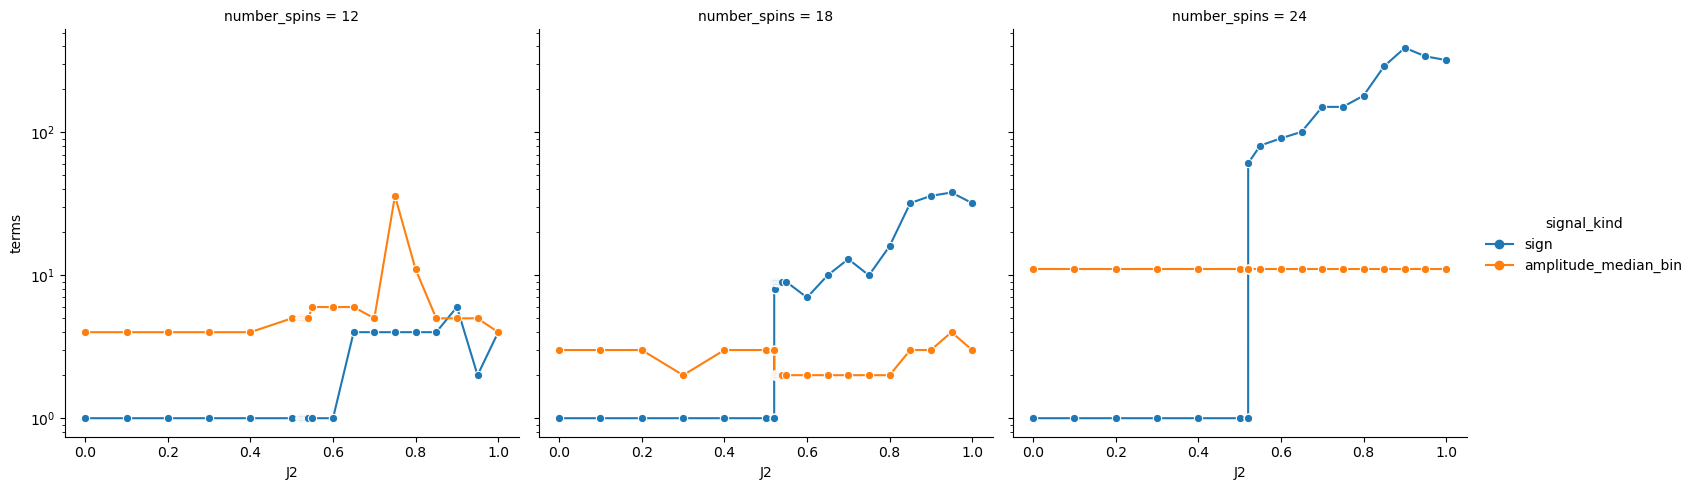

In [74]:
sns.relplot(
    analyzers_df,
    x="J2",
    y="terms",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    # markers=True,
    style="signal_kind",
    dashes=False,
    markers=["o", "o"],
    # make y axis independent
    # facet_kws=dict(sharey=False),
).set(yscale="log")


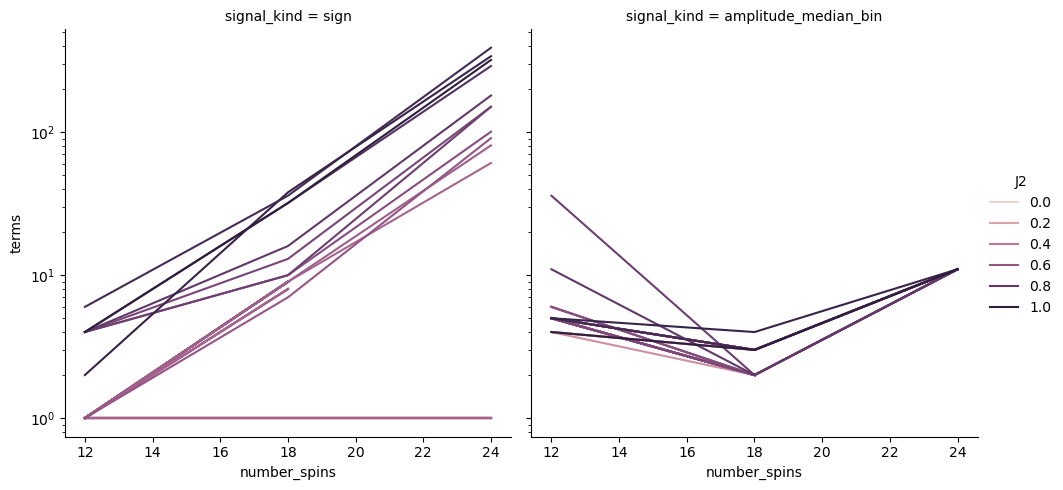

In [75]:
sns.relplot(
    analyzers_df.reset_index(),
    # .assign(J2=lambda df: df["J2"].astype(str)),
    x="number_spins",
    y="terms",
    col="signal_kind",
    hue="J2",
    kind="line",
    markers=True,
).set(yscale="log")


In [76]:
def plot_subsets(subsets, lat: SpinLattice):
    fig, axes = plt.subplots(1, len(subsets), figsize=(len(subsets) * 3, 3), squeeze=False)
    for ax, subset in zip(axes[0], subsets):
        lat.plot(spins=subset, ax=ax)
        ax.axis("off")
    return fig


In [77]:
analyzers_df


analyzer  \
height J2     signal_kind                                                               
2      0.0000 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
              amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.8000 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
              amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.3000 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
...                                                                               ...   
4      0.5205 amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.5206 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
              amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   
       0.5207 sign                  <boolean_analysis.BooleanFourierAnalyzer objec...   
              amplitude_median_bin  <boolean_analysis.BooleanFourierAnalyzer objec...   

                                    terms  accuracy  sign_overlap  \
height J2     signal_kind                                           
2      0.0000 sign                      1  1.000000      1.000000   
              amplitude_median_bin      4  0.956710      0.981367   
       0.8000 sign                      4  0.870130      0.979802   
              amplitude_median_bin     11  0.913420      0.989148   
       0.3000 sign                      1  0.991342      1.000000   
...                                   ...       ...           ...   
4      0.5205 amplitude_median_bin     11  0.872825      0.991568   
       0.5206 sign                      1  0.938717      0.999954   
              amplitude_median_bin     11  0.872825      0.991570   
       0.5207 sign                     61  0.753656      0.952950   
              amplitude_median_bin     11  0.815185      0.996850   

                                    hamming_weight  number_spins    mean_hw  
height J2     signal_kind                                                    
2      0.0000 sign                               4            12   4.000000  
              amplitude_median_bin              14            12   3.500000  
       0.8000 sign                              22            12   5.500000  
              amplitude_median_bin              34            12   3.090909  
       0.3000 sign                               4            12   4.000000  
...                                            ...           ...        ...  
4      0.5205 amplitude_median_bin              28            24   2.545455  
       0.5206 sign                               8            24   8.000000  
              amplitude_median_bin              28            24   2.545455  
       0.5207 sign                             702            24  11.508197  
              amplitude_median_bin              26            24   2.363636  

[232 rows x 7 columns]

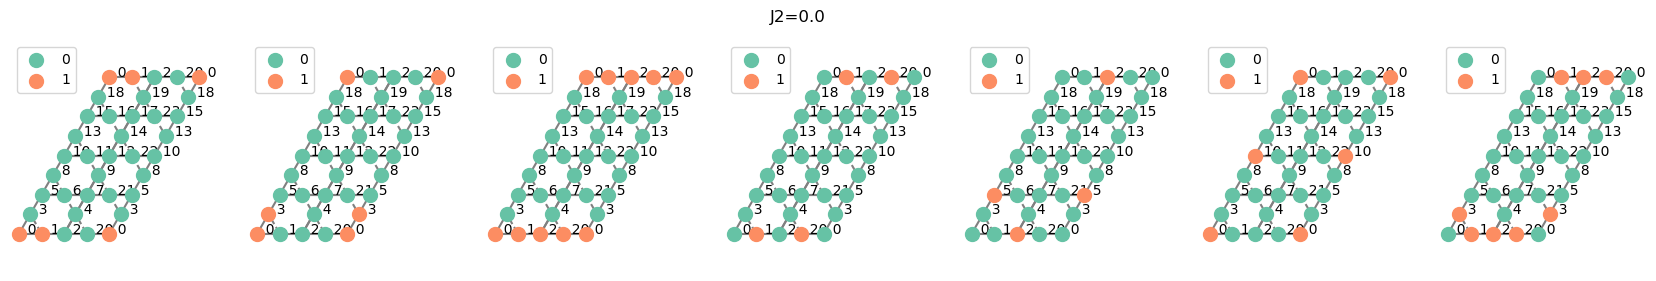

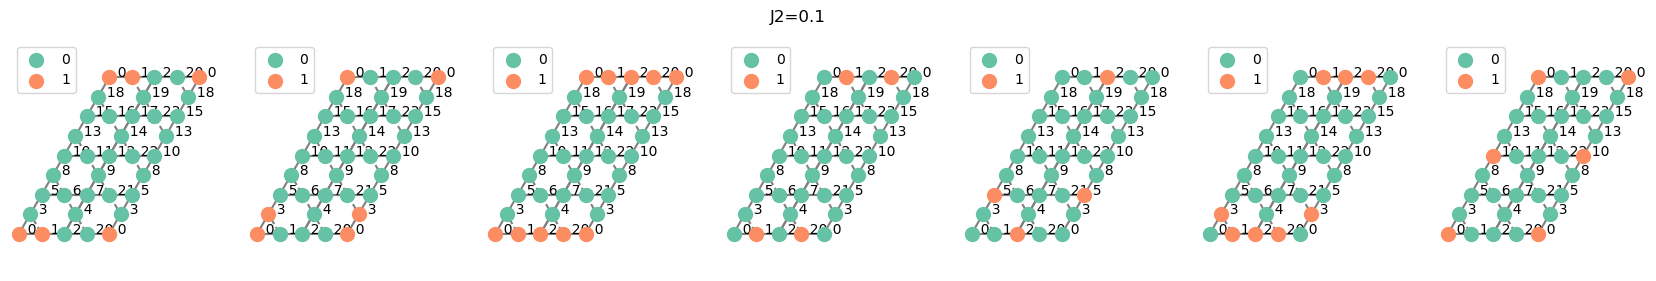

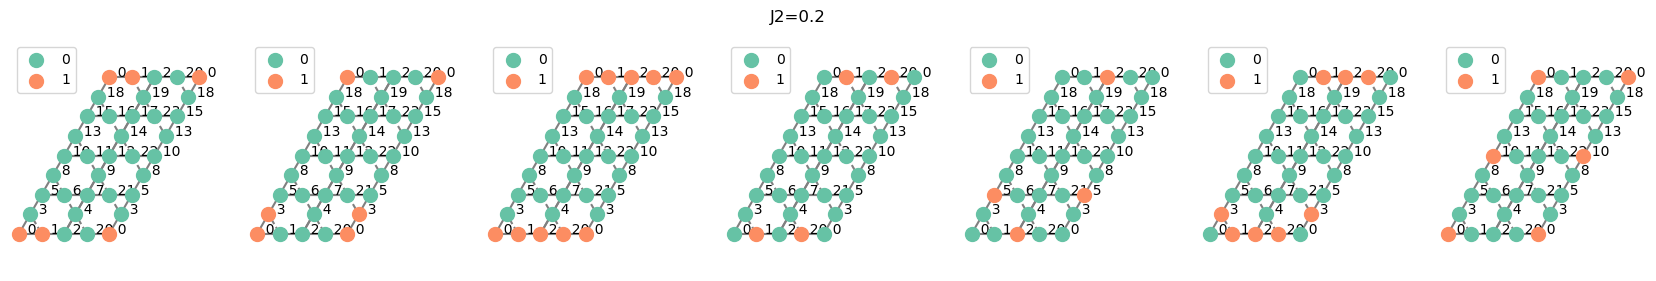

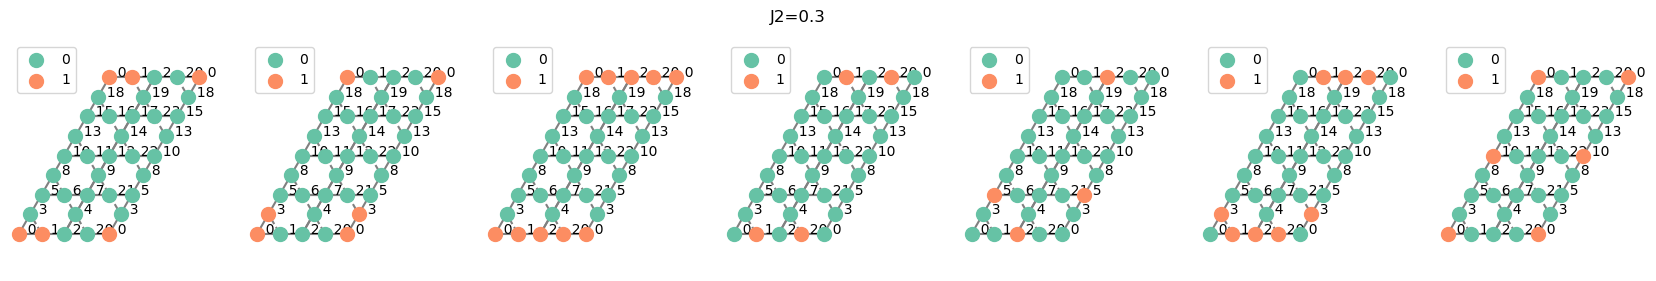

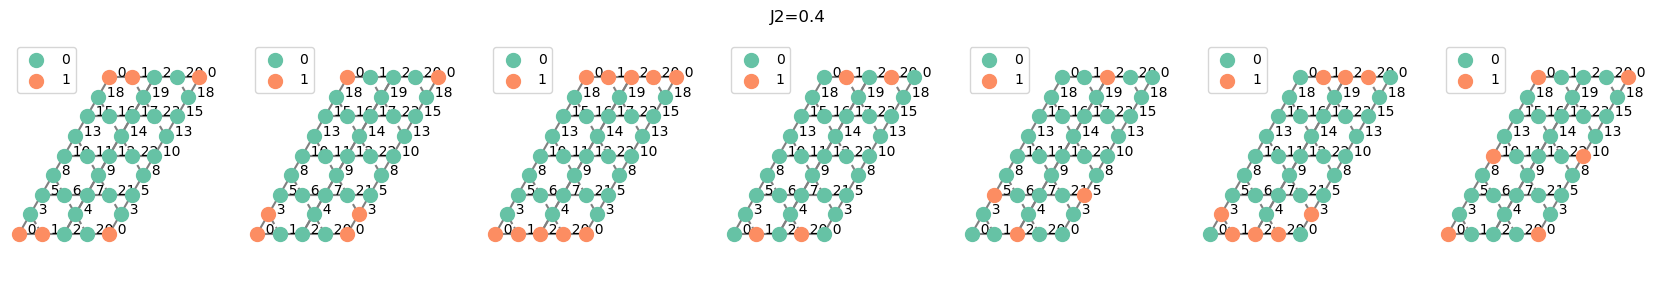

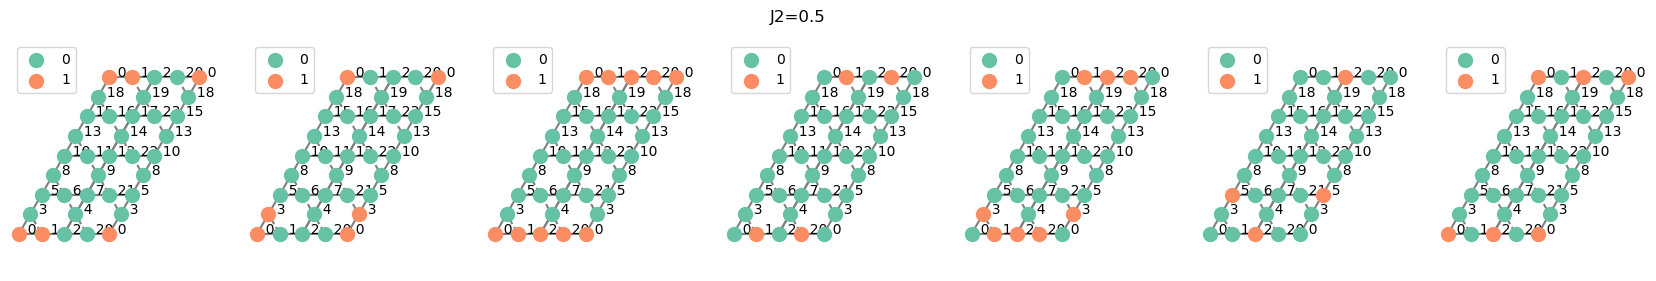

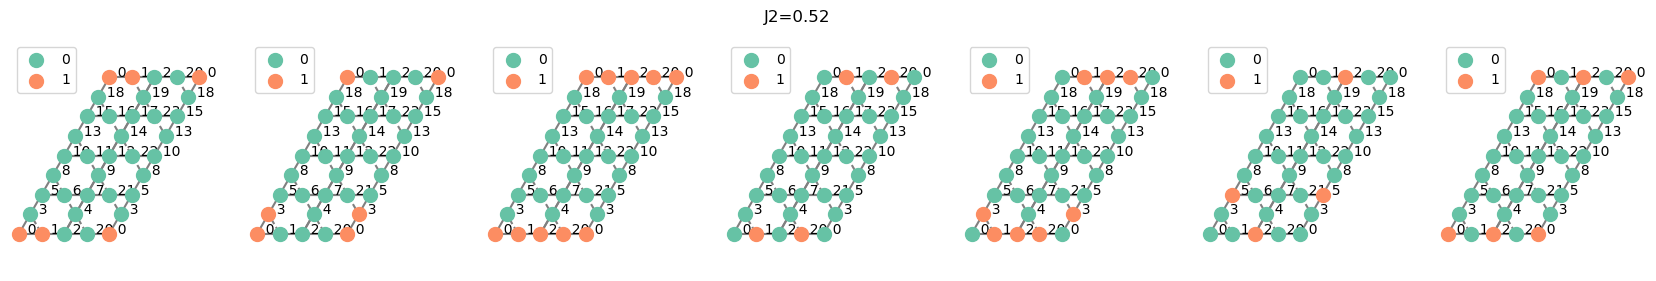

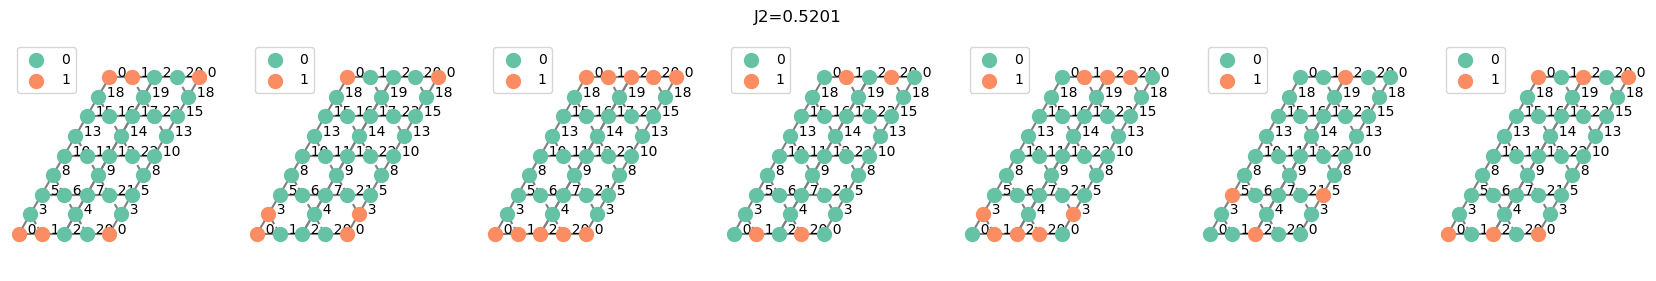

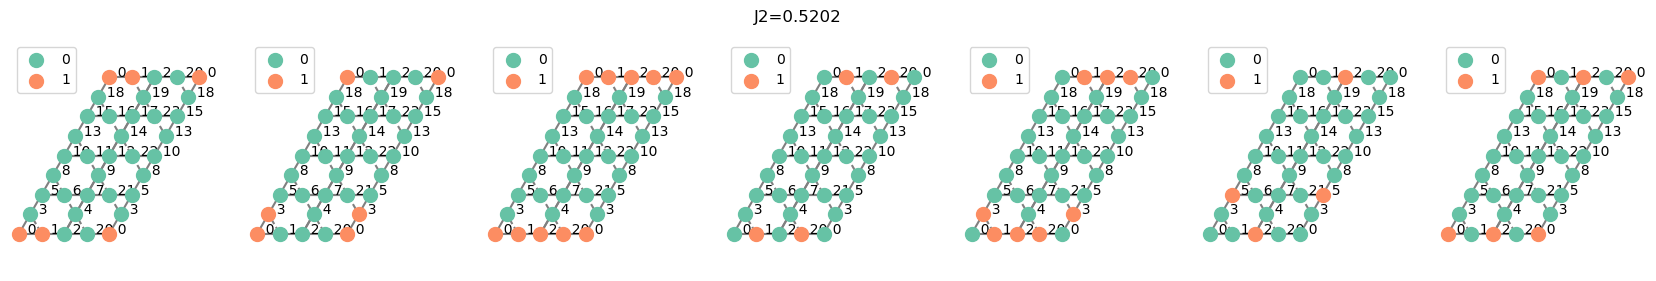

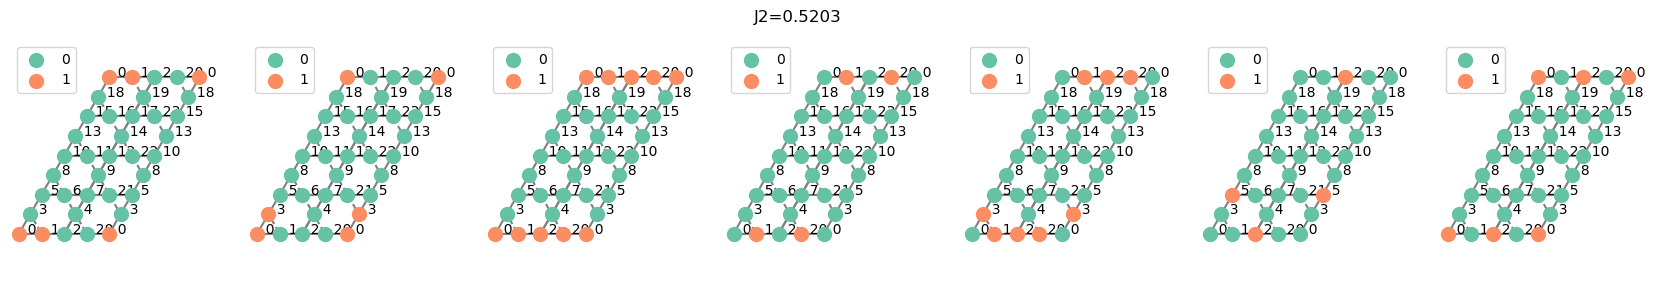

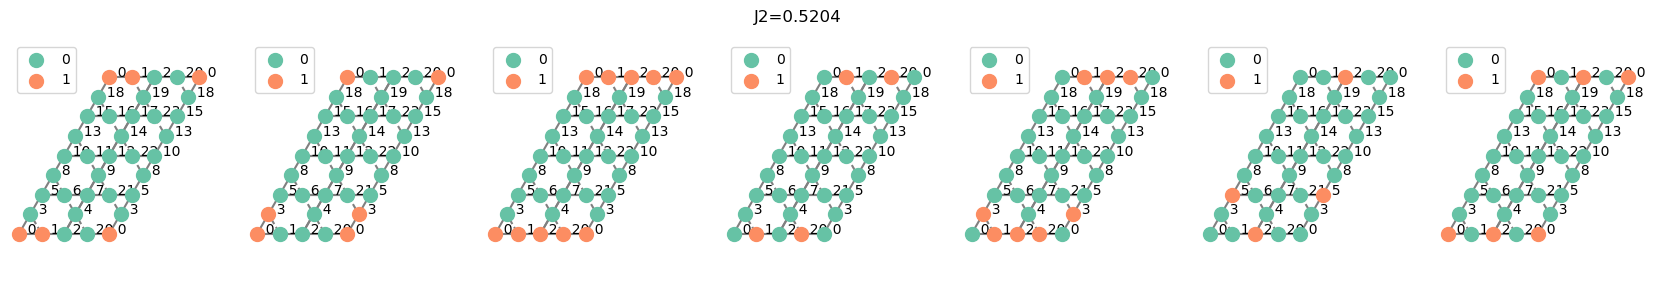

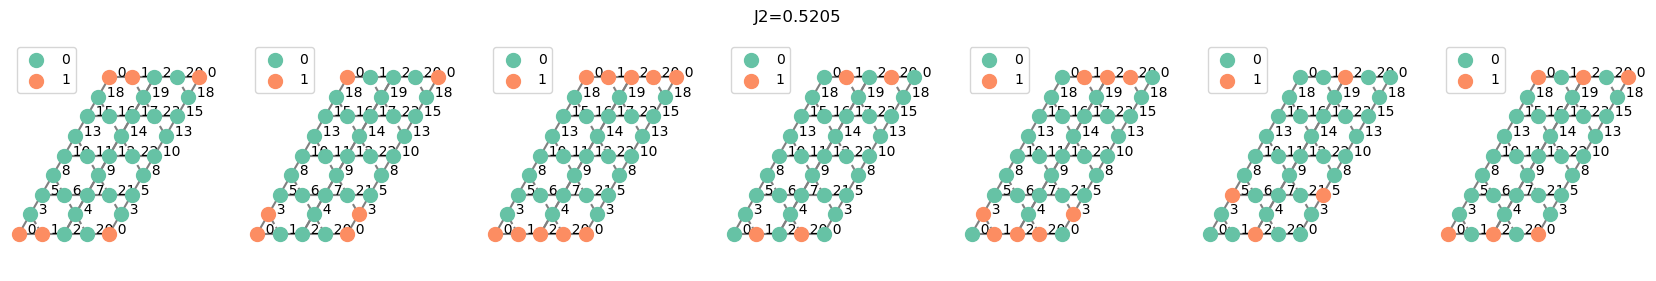

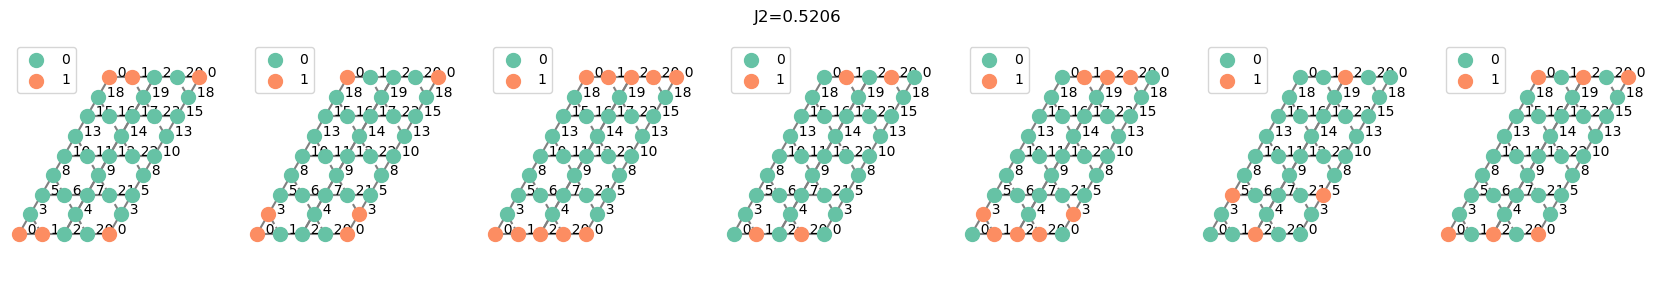

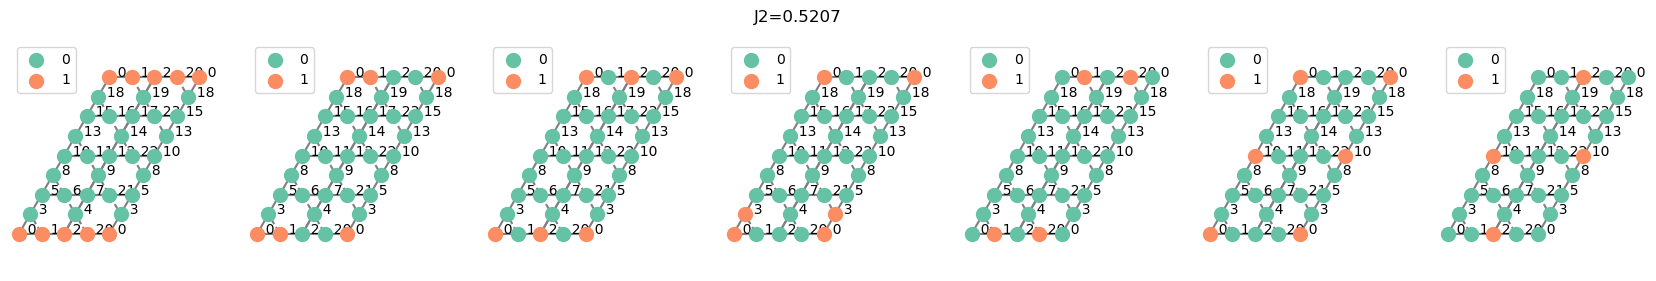

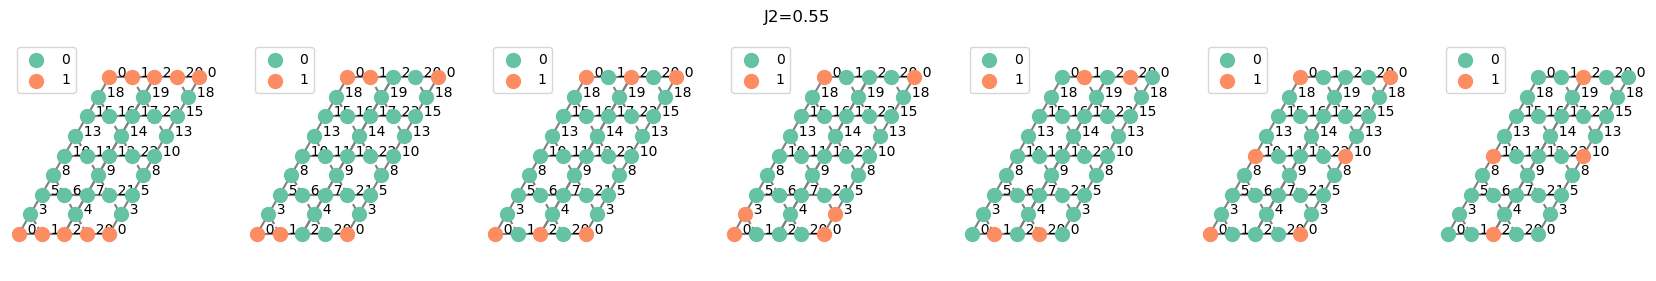

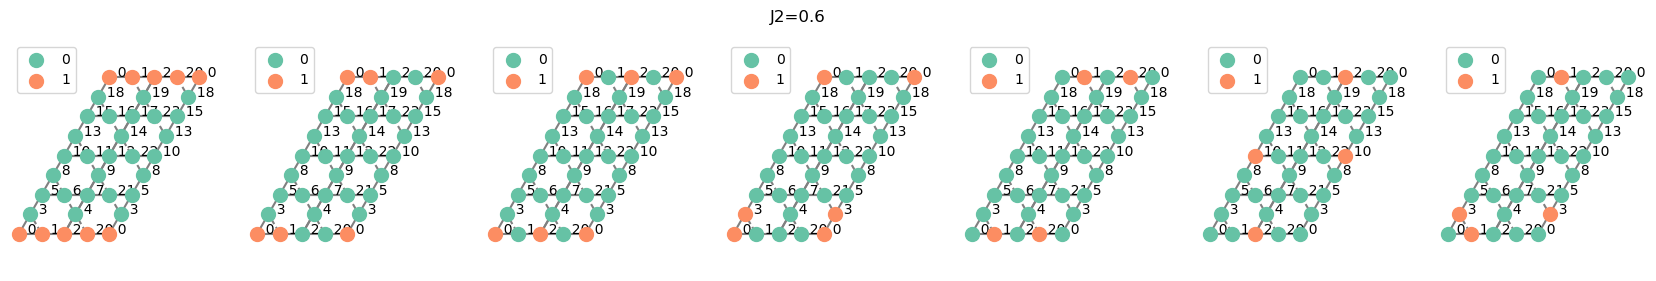

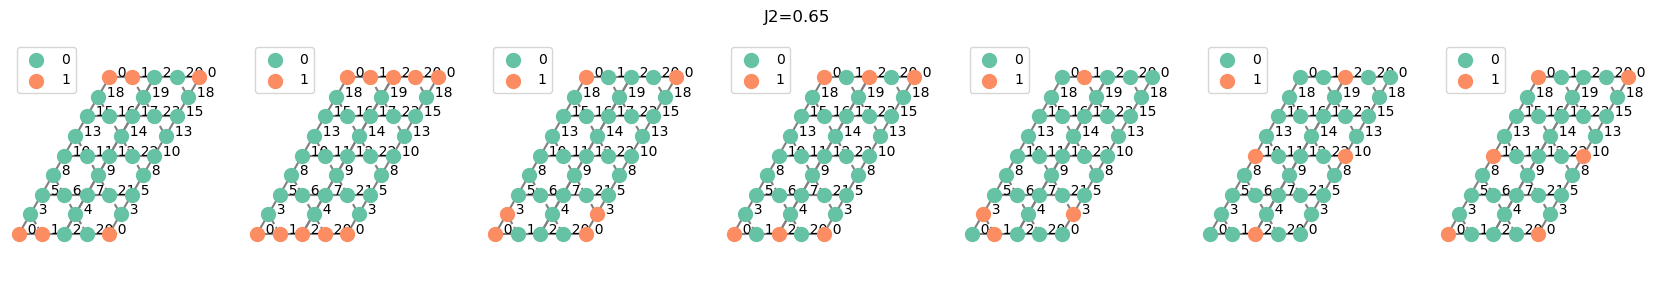

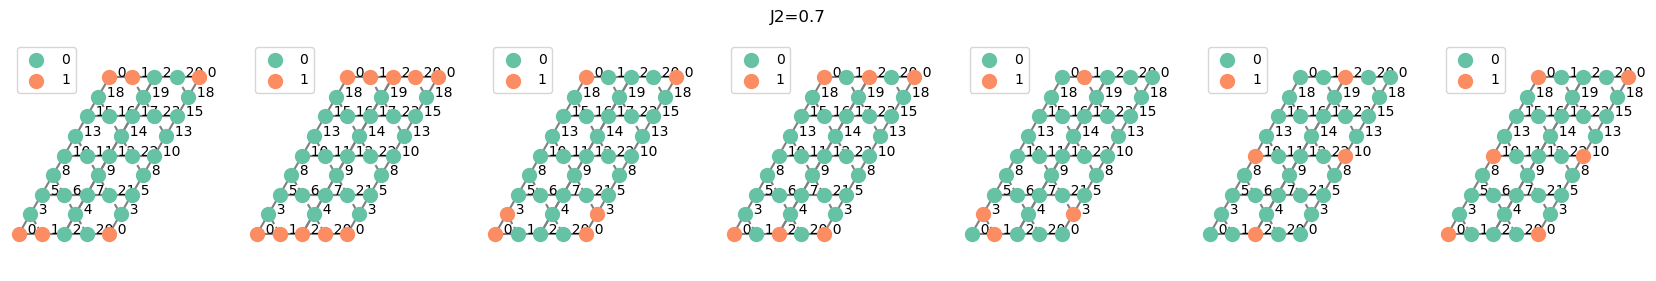

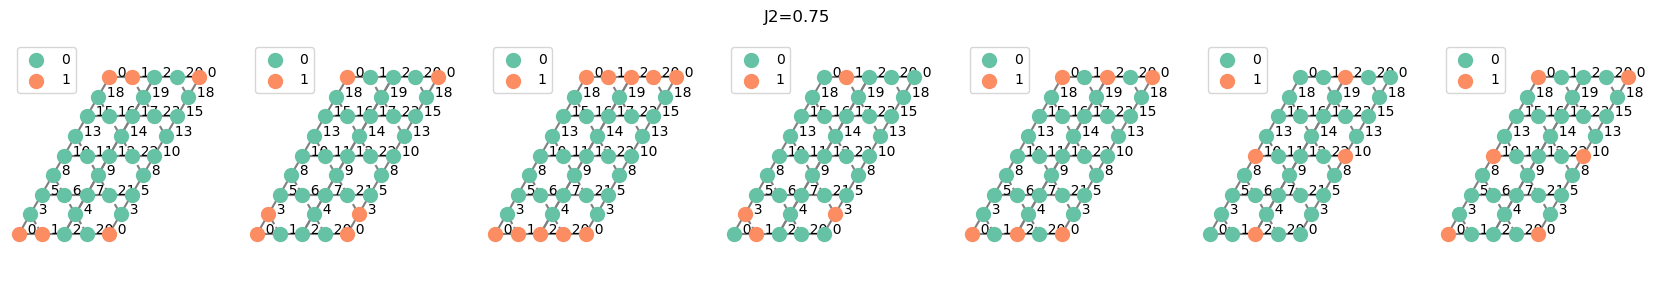

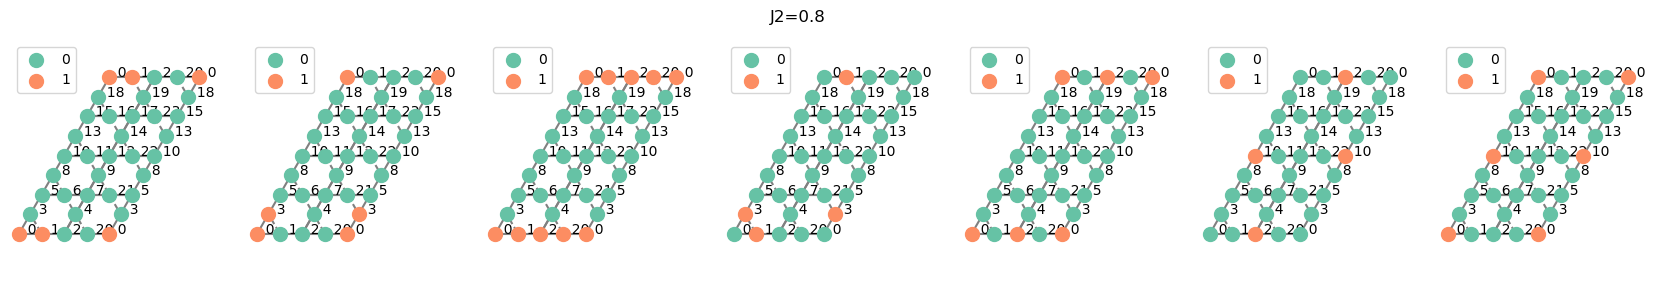

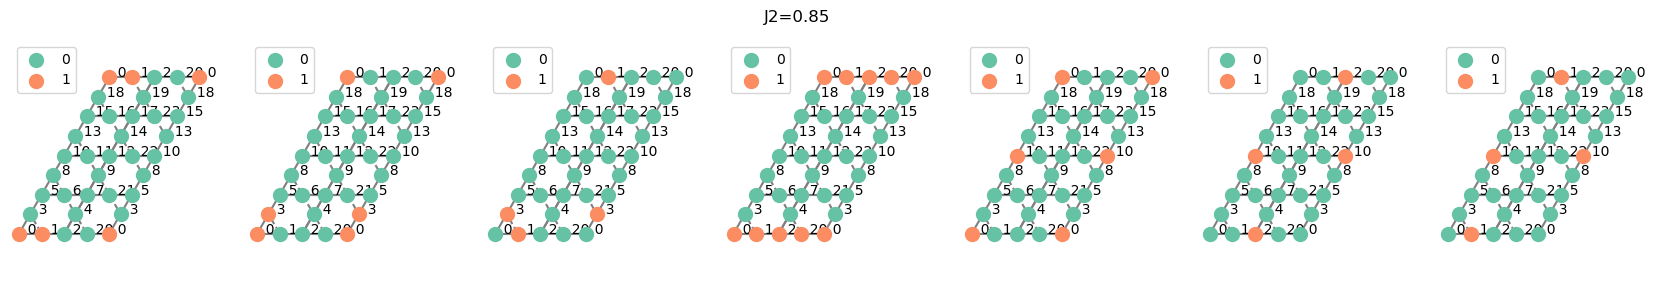

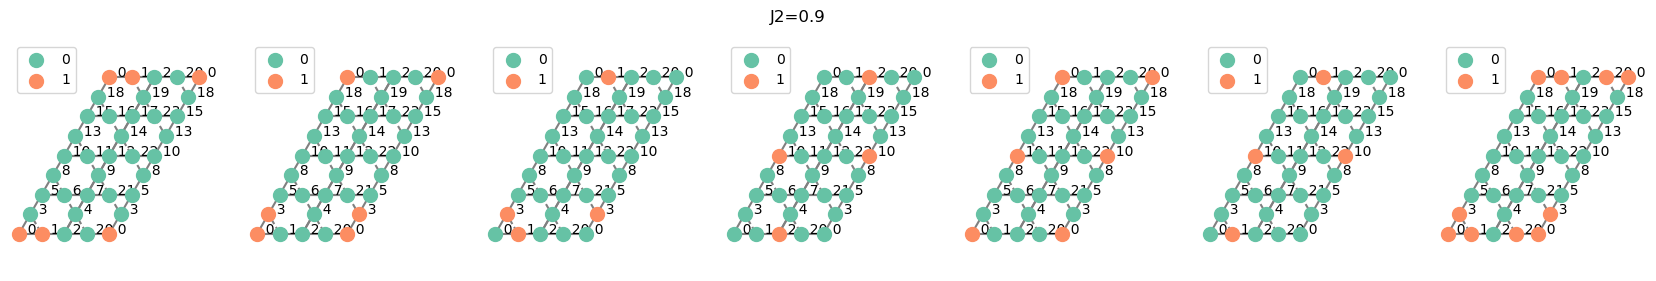

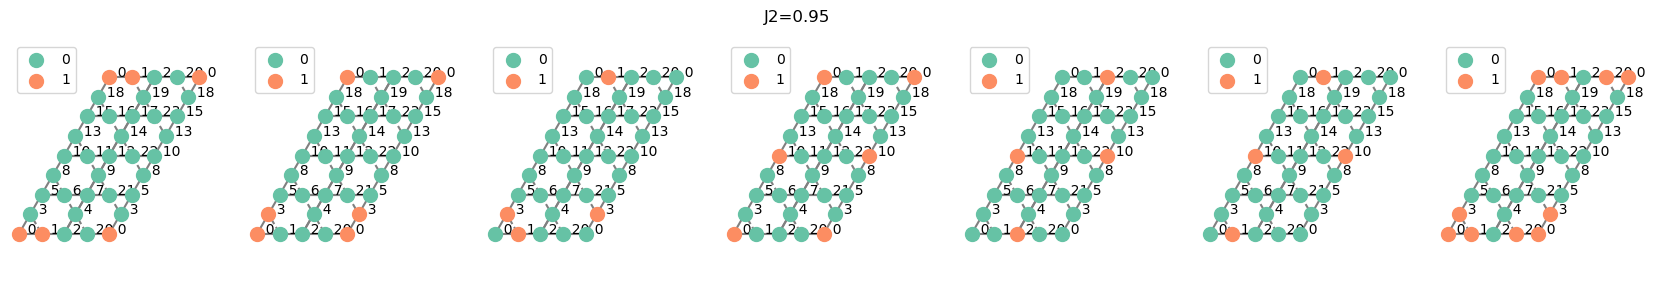

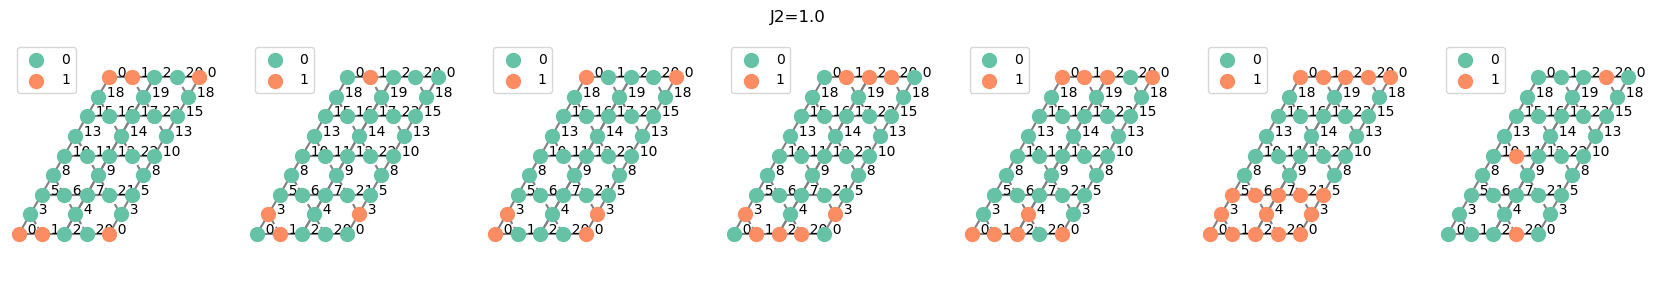

In [79]:
height = 4
signal = "amplitude_median_bin"
max_subsets = 7
# signal = "sign"
for J2, subsets in (
    analyzers_df.sort_index(level="J2")
    .xs((height, signal), level=("height", "signal_kind"))
    .assign(
        subsets=lambda df: [
            list(row["analyzer"].learner.get_coeffs_ser().iloc[: row["terms"]].index)
            for _, row in df.iterrows()
        ],
    )["subsets"]
    .items()
):
    plot_subsets(subsets[:max_subsets], KagomeLattice(width=2, height=height))
    plt.suptitle(f"J2={J2}")
    plt.show()


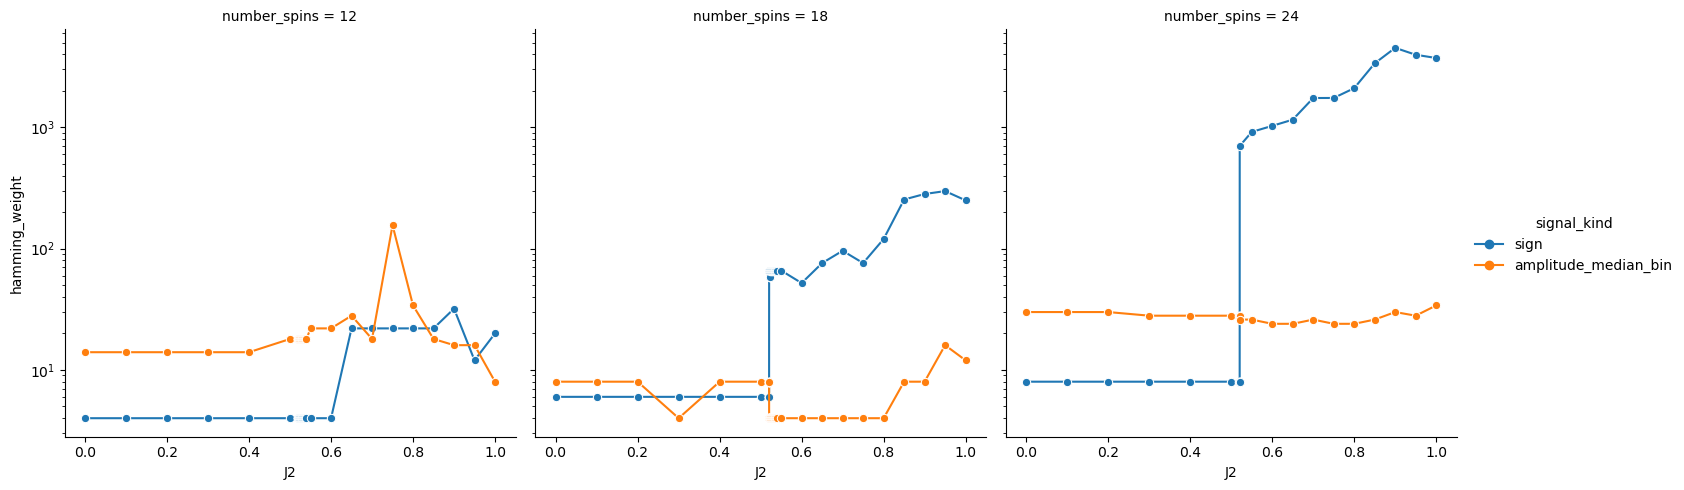

In [80]:
sns.relplot(
    analyzers_df,
    x="J2",
    y="hamming_weight",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    style="signal_kind",
    dashes=False,
    facet_kws=dict(sharex=True),
    markers=["o", "o"],
).set(yscale="log")


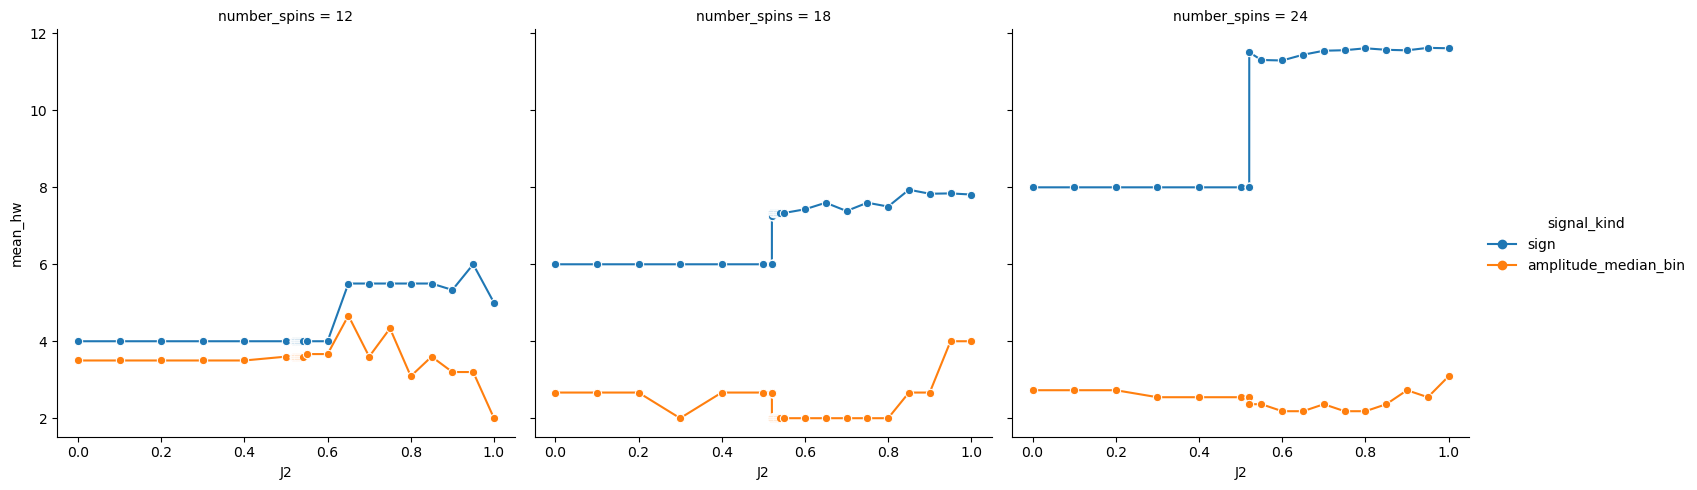

In [81]:
sns.relplot(
    analyzers_df,
    x="J2",
    y="mean_hw",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


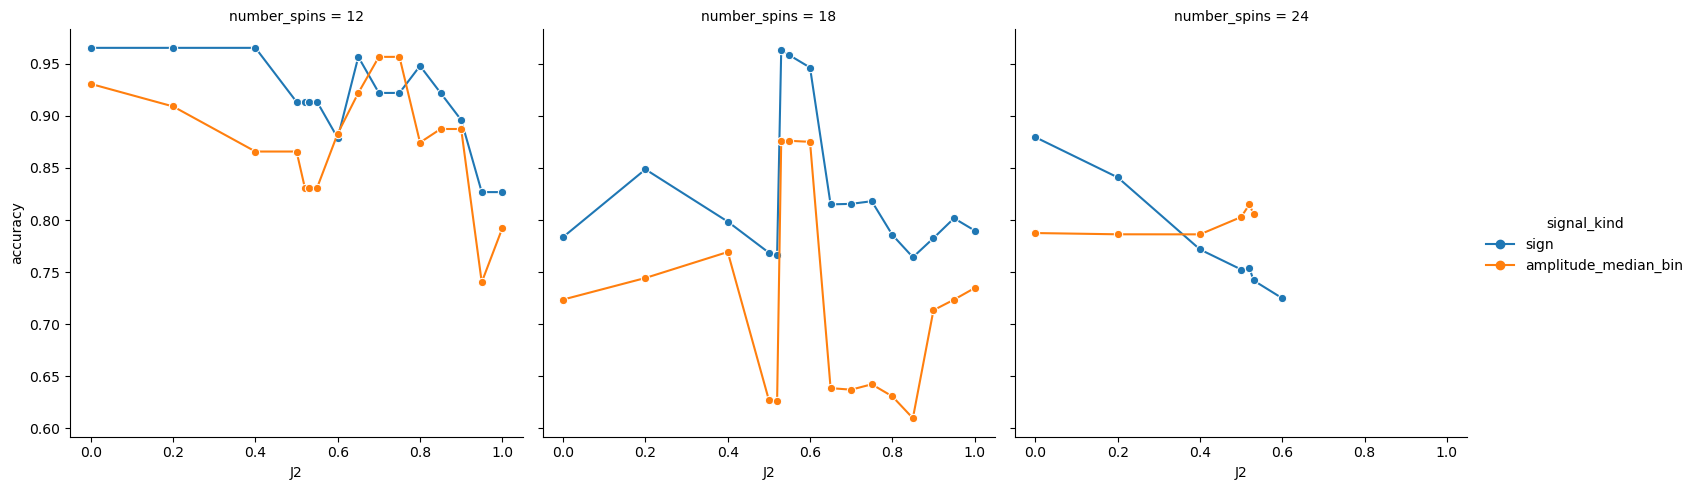

In [ ]:
sns.relplot(
    analyzers_df,
    x="J2",
    y="accuracy",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


In [ ]:
complexity_ratio_df = (
    analyzers_df.unstack(level="signal_kind")["hamming_weight"]
    .assign(ratio=lambda df: df["sign"] / df["amplitude_median_bin"])
    .reset_index()
)


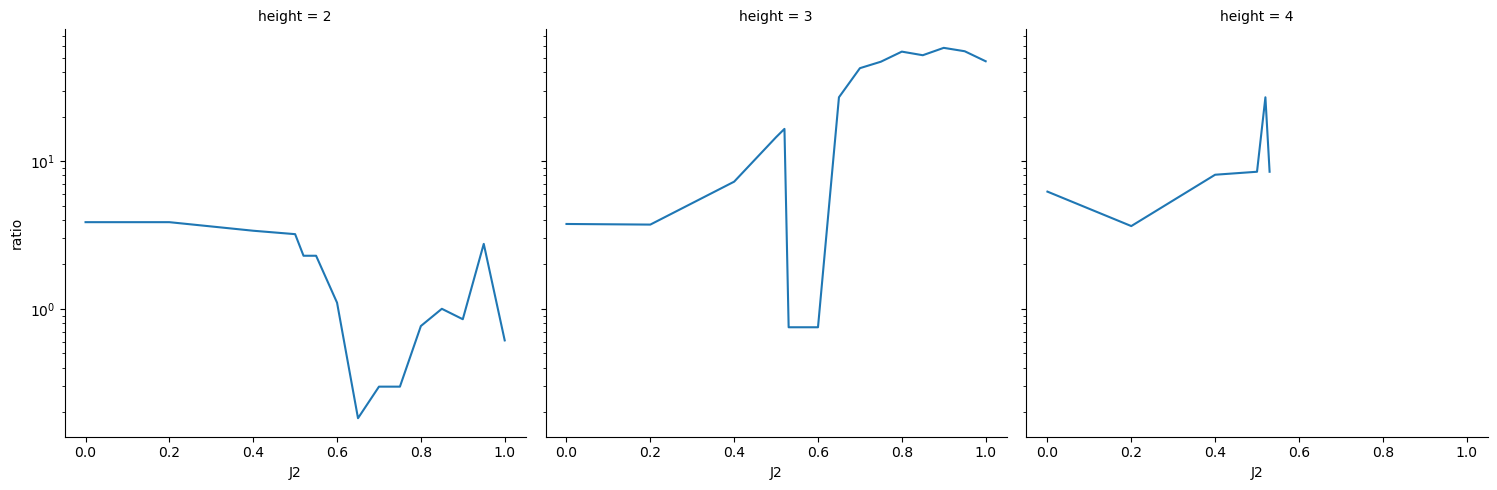

In [ ]:
sns.relplot(complexity_ratio_df, x="J2", y="ratio", col="height", kind="line").set(yscale="log")


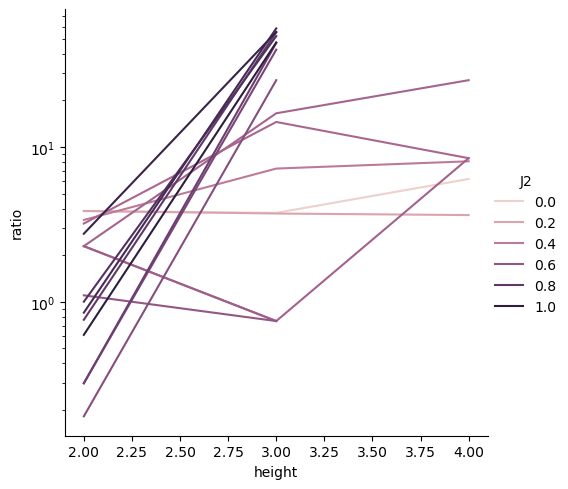

In [ ]:
sns.relplot(
    complexity_ratio_df,
    x="height",
    y="ratio",
    hue="J2",
    kind="line",
).set(yscale="log")
